# PROYECTO DE CURSO OPCIONAL: Tom and Jerry


In [ ]:
!wget --no-check-certificate https://storage.googleapis.com/platzi-tf2/TomAndJerry.zip \
    -O /tmp/TomAndJerry.zip

--2021-10-09 02:23:34--  https://storage.googleapis.com/platzi-tf2/TomAndJerry.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.196.128, 64.233.191.128, 173.194.192.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.196.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38311839 (37M) [application/zip]
Saving to: ‘/tmp/TomAndJerry.zip’

/tmp/TomAndJerry.zi 100%[===================>]  36.54M   100MB/s    in 0.4s    

2021-10-09 02:23:34 (100 MB/s) - ‘/tmp/TomAndJerry.zip’ saved [38311839/38311839]



## Descomprimir la base de datos y almacenarla en carpetas training y test
El siguiente código de Python usará la biblioteca del sistema operativo para usar las bibliotecas del sistema operativo, lo que le dará acceso al sistema de archivos y la biblioteca zipfile le permitirá descomprimir los datos.

En el siguiente código de Python utilizamos la libreria OS para poder dar acceso a los archivos del sistema operativo y luego con la libería ZipFile descomprimimos la base de datos.

In [ ]:
import os
import zipfile

local_zip = "/tmp/TomAndJerry.zip"
zip_ref = zipfile.ZipFile(local_zip, "r")
zip_ref.extractall("/tmp/TomAndJerry")
zip_ref.close()

#### Cargamos librerías

In [ ]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Buscamos la dirección de nuestra base de datos
En este caso la base de datos esta distruibuida en training y test. Cada carpeta contiene otra subcarpeta en donde se tiene cada una de las clases de la base de datos. 

In [ ]:
train_dir = "/tmp/TomAndJerry/Train"
test_dir = "/tmp/TomAndJerry/Test"

## Data Generators
Configuremos generadores de datos que leerán imágenes en nuestras carpetas de origen, las convertirán en tensores `float32` y las alimentarán (con sus etiquetas) a nuestra red. Tendremos un generador para las imágenes de entrenamiento y otro para las imágenes de validación. Nuestros generadores producirán lotes de imágenes de tamaño 28x28 y sus etiquetas.

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1/255)
test_datagen = ImageDataGenerator(rescale = 1/255, validation_split= 0.2)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (640, 480),
    batch_size = 64,
    class_mode = "categorical",
    color_mode = "grayscale",
    subset = "training"
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (640, 480),
    batch_size = 64,
    class_mode = "categorical",
    color_mode = "grayscale",
    subset = "validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (640, 480),
    batch_size = 64,
    class_mode = "categorical",
    color_mode = "grayscale"
)

Found 301 images belonging to 2 classes.
Found 7 images belonging to 2 classes.
Found 42 images belonging to 2 classes.


#### Definimos las clases de nuestra base de datos

In [ ]:
classes = ["Tom", "Jerry"]

## Visualizamos la data

In [ ]:
def plotImages(images_arr):
  fig, axes = plt.subplots(1, 5, figsize = (10, 10))
  axes = axes.flatten()
  for img, ax in zip(images_arr, axes):
    ax.imshow(img[:,:,0])
    ax.axis("off")
  plt.tight_layout()
  plt.show()

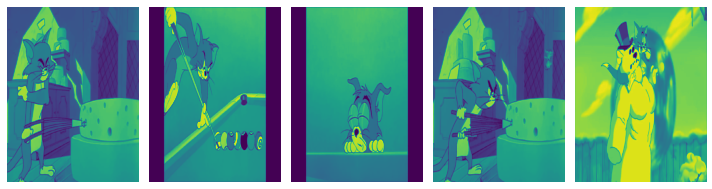

In [ ]:
sample_training_images, _= next(train_generator)
plotImages(sample_training_images[:5])

## Creamos nuestro modelo funcional base

In [ ]:
model_base = tf.keras.models.Sequential([
              tf.keras.layers.Flatten(input_shape= (640, 480, 1)),
              tf.keras.layers.Dense(256, activation = "relu"),
              tf.keras.layers.Dense(128, activation = "relu"),
              tf.keras.layers.Dense(len(classes), activation = "softmax")
])

In [ ]:
model_base.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 307200)            0         
_________________________________________________________________
dense (Dense)                (None, 256)               78643456  
_________________________________________________________________
dense_1 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 258       
Total params: 78,676,610
Trainable params: 78,676,610
Non-trainable params: 0
_________________________________________________________________


## Entrenamiento
Entrenemos durante 10 épocas. Esto puede tardar unos minutos en ejecutarse.

In [ ]:
model_base.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ['accuracy'])


history = model_base.fit(
    train_generator, 
    epochs= 20, 
    validation_data = validation_generator
)

Epoch 1/20
5/5 [==============================] - 7s 896ms/step - loss: 93.9797 - accuracy: 0.5714 - val_loss: 7.4263 - val_accuracy: 0.5714
Epoch 2/20
5/5 [==============================] - 5s 976ms/step - loss: 90.5555 - accuracy: 0.4585 - val_loss: 62.6100 - val_accuracy: 0.5714
Epoch 3/20
5/5 [==============================] - 5s 959ms/step - loss: 46.6229 - accuracy: 0.6179 - val_loss: 9.1949 - val_accuracy: 0.4286
Epoch 4/20
5/5 [==============================] - 5s 1s/step - loss: 33.7234 - accuracy: 0.4950 - val_loss: 32.7226 - val_accuracy: 0.5714
Epoch 5/20
5/5 [==============================] - 5s 970ms/step - loss: 16.7215 - accuracy: 0.5914 - val_loss: 4.2778 - val_accuracy: 0.7143
Epoch 6/20
5/5 [==============================] - 5s 985ms/step - loss: 9.0518 - accuracy: 0.6678 - val_loss: 8.3486 - val_accuracy: 0.4286
Epoch 7/20
5/5 [==============================] - 5s 973ms/step - loss: 17.6297 - accuracy: 0.5249 - val_loss: 13.1597 - val_accuracy: 0.5714
Epoch 8/20
5/5

## Testeamos el modelo

In [ ]:
results = model_base.evaluate(test_generator)

1/1 [==============================] - 1s 700ms/step - loss: 1.1553 - accuracy: 0.6667


## Generamos una clase para visualizar y analizar los resultados

In [ ]:
def visualizacion_resultados(history):
  epochs = [i for i in range(20)]
  fig, ax = plt.subplots(1,2)
  train_acc = history.history["accuracy"]
  train_loss = history.history["loss"]
  val_acc = history.history["val_accuracy"]
  val_loss = history.history["val_loss"]
  fig.set_size_inches(16, 9)

  ax[0].plot(epochs, train_acc, "go-", label =" Entrenamiento accuracy")
  ax[0].plot(epochs, val_acc, "ro-", label= "Validacion accuracy")
  ax[0].set_title("Entrenamiento & validación accuracy")
  ax[0].legend()
  ax[0].set_xlabel("Epochs")
  ax[0].set_ylabel("Accuracy")

  ax[1].plot(epochs, train_loss, "go-", label =" Entrenamiento Loss")
  ax[1].plot(epochs, val_loss, "ro-", label= "Validacion Loss")
  ax[1].set_title("Entrenamiento & validación Loss")
  ax[1].legend()
  ax[1].set_xlabel("Epochs")
  ax[1].set_ylabel("Loss")

  plt.show()


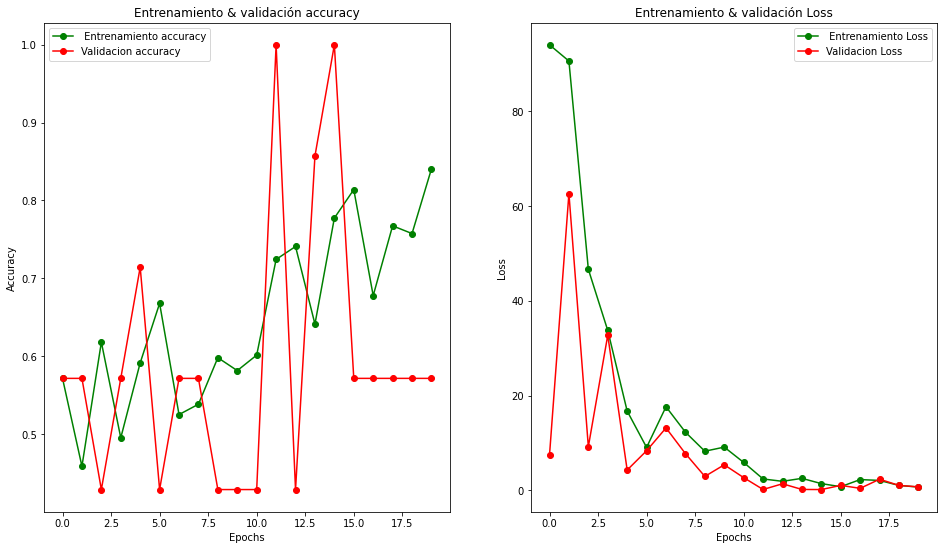

In [ ]:
visualizacion_resultados(history)

## Creamos nuestro modelo con regularizadores

In [ ]:
from tensorflow.keras import regularizers

In [ ]:
model_optimizer = tf.keras.models.Sequential([
              tf.keras.layers.Flatten(input_shape= (640, 480, 1)),
              tf.keras.layers.Dense(256, kernel_regularizer = regularizers.l2(1e-5), activation = "relu"),
              tf.keras.layers.Dropout(0.2),
              tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5),activation = "relu"),
              tf.keras.layers.Dropout(0.2),
              tf.keras.layers.Dense(len(classes), activation = "softmax")
])

model_optimizer.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 307200)            0         
_________________________________________________________________
dense_3 (Dense)              (None, 256)               78643456  
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 128)               32896     
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_5 (Dense)              (None, 2)                 258       
Total params: 78,676,610
Trainable params: 78,676,610
Non-trainable params: 0
__________________________________________

In [ ]:
model_optimizer.compile(optimizer= "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

history_optimizer = model_optimizer.fit(
    train_generator,
    epochs = 20,
    validation_data = validation_generator
)

Epoch 1/20
5/5 [==============================] - 6s 1s/step - loss: 77.0533 - accuracy: 0.5449 - val_loss: 60.0456 - val_accuracy: 0.5714
Epoch 2/20
5/5 [==============================] - 5s 952ms/step - loss: 54.6292 - accuracy: 0.5216 - val_loss: 12.4341 - val_accuracy: 0.5714
Epoch 3/20
5/5 [==============================] - 5s 956ms/step - loss: 27.0594 - accuracy: 0.6113 - val_loss: 14.4481 - val_accuracy: 0.5714
Epoch 4/20
5/5 [==============================] - 5s 1s/step - loss: 27.3188 - accuracy: 0.5150 - val_loss: 19.8115 - val_accuracy: 0.5714
Epoch 5/20
5/5 [==============================] - 5s 971ms/step - loss: 23.9168 - accuracy: 0.5880 - val_loss: 2.2903 - val_accuracy: 0.7143
Epoch 6/20
5/5 [==============================] - 5s 962ms/step - loss: 20.1051 - accuracy: 0.5548 - val_loss: 12.2538 - val_accuracy: 0.5714
Epoch 7/20
5/5 [==============================] - 5s 949ms/step - loss: 19.1682 - accuracy: 0.5382 - val_loss: 5.1145 - val_accuracy: 0.4286
Epoch 8/20
5/5

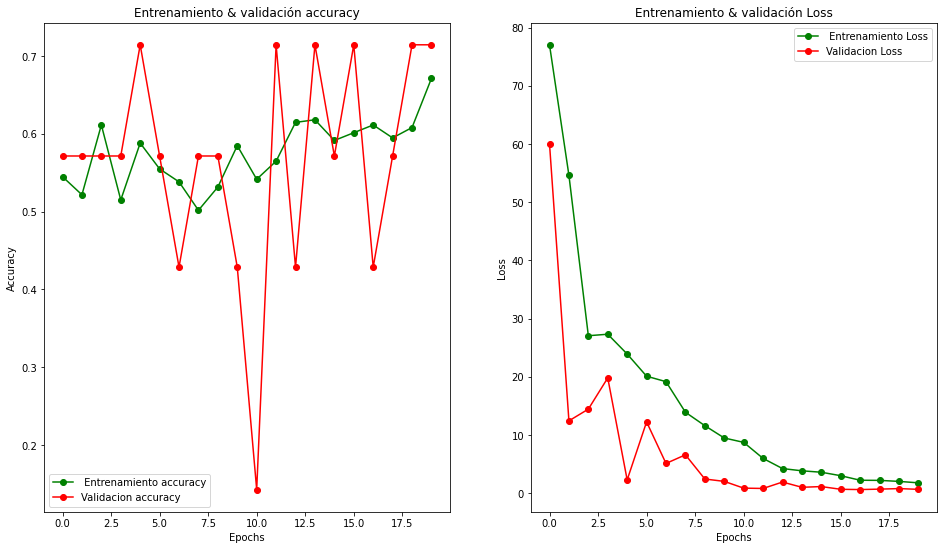

In [ ]:
visualizacion_resultados(history_optimizer)

## Creamos nuestro modelo con convoluciones

In [ ]:
model_convolutional = tf.keras.models.Sequential([
              tf.keras.layers.Conv2D(75, (3,3), activation = "relu", input_shape= (640, 480, 1)),
              tf.keras.layers.MaxPool2D((2,2)),
              tf.keras.layers.Flatten(),
              tf.keras.layers.Dense(256, kernel_regularizer = regularizers.l2(1e-5), activation = "relu"),
              tf.keras.layers.Dropout(0.2),
              tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5),activation = "relu"),
              tf.keras.layers.Dropout(0.2),
              tf.keras.layers.Dense(len(classes), activation = "softmax")
])

model_convolutional.summary()

model_convolutional.compile(optimizer= "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

history_convolutional = model_convolutional.fit(
    train_generator,
    epochs = 3,
    validation_data = validation_generator
)

ResourceExhaustedError: ignored

In [ ]:
visualizacion_resultados(history_convolutional)

## Calbacks personalizados
Link para visualizar más callbacks [aqui](https://colab.research.google.com/drive/1OYndV_bH8tDv5Qi8yxuoq4VzVUpsi82A?authuser=1).

In [ ]:
model_callback = tf.keras.models.Sequential([
              tf.keras.layers.Conv2D(75, (3,3), activation = "relu", input_shape= (640, 480, 1)),
              tf.keras.layers.MaxPool2D((2,2)),
              tf.keras.layers.Flatten(),
              tf.keras.layers.Dense(256, kernel_regularizer = regularizers.l2(1e-5), activation = "relu"),
              tf.keras.layers.Dropout(0.2),
              tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5),activation = "relu"),
              tf.keras.layers.Dropout(0.2),
              tf.keras.layers.Dense(len(classes), activation = "softmax")
])

model_callback.summary()

model_callback.compile(optimizer= "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
from tensorflow.keras.callbacks import Callback

class TrainingCallback(Callback):
  def on_epoch_end(self, epoch, logs = {}):
    if logs.get("accuracy") > 0.95:
      print("Lo logramos, nuestro modelo llego a 95%, detenemos el entrenamiento")
      self.model.stop_training = True


In [ ]:
callback = TrainingCallback()

history_callback = model_callback.fit(
    train_generator,
    epochs = 20,
    callbacks = [callback],
    validation_data = validation_generator
)

In [ ]:
def get_model():
  model = tf.keras.models.Sequential([
              tf.keras.layers.Conv2D(75, (3,3), activation = "relu", input_shape= (640, 480, 1)),
              tf.keras.layers.MaxPool2D((2,2)),
              tf.keras.layers.Flatten(),
              tf.keras.layers.Dense(256, kernel_regularizer = regularizers.l2(1e-5), activation = "relu"),
              tf.keras.layers.Dropout(0.2),
              tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5),activation = "relu"),
              tf.keras.layers.Dropout(0.2),
              tf.keras.layers.Dense(len(classes), activation = "softmax")
  ])
  return model

model_early = get_model()
model_early.summary()

model_early.compile(optimizer= "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

## Early stopping

In [ ]:
callback_early = tf.keras.callbacks.EarlyStopping(monitor = "loss", patience=3, mode = "auto")

In [ ]:
history_early = model_early.fit(
    train_generator, 
    epochs= 20, 
    callbacks = [callback_early],
    validation_data = validation_generator
)

## Creamos nuestra modelo funcional con Auto Tunner Keras

In [ ]:
!pip install -q -U keras-tuner
import kerastuner as kt
from tensorflow import keras

In [ ]:
def constructor_modelos(hp):
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Conv2D(75, (3,3), activation= "relu", input_shape = (640, 480, 1)))
  model.add(tf.keras.layers.MaxPool2D((2,2)))
  model.add(tf.keras.layers.Flatten())

  hp_units = hp.Int("units", min_value = 32, max_value = 512, step = 32)
  model.add(tf.keras.layers.Dense(units=hp_units,activation = "relu", kernel_regularizer= regularizers.l2(1e-5)))
  model.add(tf.keras.layers.Dropout(0.2))
  model.add(tf.keras.layers.Dense(128,activation = "relu", kernel_regularizer= regularizers.l2(1e-5)))
  model.add(tf.keras.layers.Dropout(0.2))
  model.add(tf.keras.layers.Dense(len(classes), activation = "softmax"))

  hp_learning_rate = hp.Choice('learning_rate', values = [1e-2, 1e-3, 1e-4])

  model.compile(optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate),loss = "categorical_crossentropy", metrics = ["accuracy"])

  return model


In [ ]:
tuner = kt.Hyperband(
    constructor_modelos,
    objective = "val_accuracy",
    max_epochs = 20,
    factor = 3,
    directory = "models/",
    project_name = "platzi-tunner"
)

In [ ]:
tuner.search(train_generator, epochs =20, validation_data = validation_generator)

best_hps = tuner.get_best_hyperparameters(num_trials =1)[0]

In [ ]:
print(best_hps.get("units"))

In [ ]:
print(best_hps.get("learning_rate"))

In [ ]:
hypermodel = tuner.hypermodel.build(best_hps)

history_hypermodel = hypermodel.fit(
    train_generator,
    epochs = 20,
    callbacks = [callback_early],
    validation_data = validation_generator
)

## Guardar únicamente arquitectura del modelo

In [ ]:
config_dict = hypermodel.get_config()

In [ ]:
print(config_dict)

## Crear un nuevo modelo desde la arquitectura

In [ ]:
model_same_config = tf.keras.Sequential.from_config(config_dict)

In [ ]:
model_same_config.summary()

### Lecturas adicionales para almacenamiento de arquitectura
* https://www.tensorflow.org/guide/keras/save_and_serialize#architecture-only_saving
* https://keras.io/getting-started/faq/#how-can-i-save-a-keras-model

## Guardar y cargar únicamente los pesos
#### Entrenar el modelo con los checkpoints

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
model_weight = get_model()
model_weight.summary()

In [ ]:
model_weight.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
# Creamos unos checkpoint de nuestros modelos con TensorFlow, verbose: mostrar mas información
checkpoint_path = "model_checpoints/checkpoint"
checkpoint_weighs= ModelCheckpoint(
    filepath = checkpoint_path,
    frecuency = "epoch",
    save_weights_only = True,
    verbose = 1

)

In [ ]:
# Entrenamos el modelo, y almacenamos en cada steps los pesos del moedelo.
history_weight = model_weight.fit(
    train_generator,
    epochs = 20,
    callbacks = [checkpoint_weighs],
    validation_data = validation_generator
)


#### Guardamos los pesos de forma manual

In [ ]:
model_weight.save_weights("model_manul/my_model")

#### Creamos la arquitectura y cargamos los pesos

In [ ]:
model_weights2 = get_model()
model_weights2.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
model_weights2.load_weights(checkpoint_path)


In [ ]:
model_weights2.evaluate(test_generator)

In [ ]:
model_weight.evaluate(test_generator)

## Criterios para almacenar modelos
#### Almacenar infraestructura y peso

In [ ]:
checkpoint_path = "model_checpoints_complete"
checkpoint_weighs= ModelCheckpoint(
    filepath = checkpoint_path,
    frecuency = "epoch",
    save_weights_only = False,
    monitor = "val_accuracy",
    save_best_only = True,
    verbose = 1

)

In [ ]:
model_complete = get_model()
model_complete.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

history_complete = model_complete.fit(
    train_generator,
    epochs = 20,
    callbacks = [checkpoint_weighs],
    validation_data = validation_generator
)

#### Almacenar infraestructura y peso manual

In [ ]:
model_complete.save("saved_model_complete/mymodel")

#### Cargamos nuestro modelo completo

In [ ]:
model_complete3 = tf.keras.models.load_model("saved_model_complete/mymodel")

In [ ]:
model_complete3.evaluate(test_generator)

In [ ]:
model_complete.evaluate(test_generator)

#### Usar el formato .h5 para guardar modelos
Hierarchical Data Format (HDF5 format)

In [ ]:
!pip install pyyaml h5py

In [ ]:
model_complete3.save("my_model.h5")

In [ ]:
model_complete4 = tf.keras.models.load_model("my_model.h5")

## Creamos nuestra modelo pre-entrenado con modelos de Keras
#### Preprocesamiento de nuestra base de datos
Debemos revisar cual es el input de nuestro modelos (Tamaño del tensor de entrada)

In [ ]:
train_generator_resize = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150, 150),
    batch_size = 128,
    class_mode = "categorical",
    color_mode = "rgb",
    subset = "training"
)

validation_generator_resize = test_datagen.flow_from_directory(
    test_dir,
    target_size = (150, 150),
    batch_size = 128,
    class_mode = "categorical",
    color_mode = "rgb",
    subset = "validation"
)

test_generator_resize = test_datagen.flow_from_directory(
    test_dir,
    target_size = (150, 150),
    batch_size = 128,
    class_mode = "categorical",
    color_mode = "rgb"
)

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

pre_trained_model = InceptionV3(
    include_top = False,
    input_tensor = tf.keras.layers.Input(shape = (150, 150, 3))
)

for layer in pre_trained_model.layers:
  layer.trainable = False

pre_trained_model.summary()

#### Congelamos el modelo 
Congelamos hasta la capa mixed 7 para agregar nuestra capas de salida

In [ ]:
last_layers= pre_trained_model.get_layer("mixed7")
last_output = last_layers.output

In [ ]:
x = tf.keras.layers.Flatten()(last_output)
x = tf.keras.layers.Dense(128, activation = "relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(len(classes), activation= "softmax")(x)

model_keras = tf.keras.Model(pre_trained_model.input, x)

model_keras.compile(optimizer= "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])
model_keras.summary()

In [ ]:
history_keras = model_keras.fit(
    train_generator_resize,
    epochs = 5,
    validation_data = validation_generator_resize
)

In [ ]:
results = model_keras.evaluate(test_generator_resize)

## Creamos nuestra modelo pre-entrenado con modelos desde TensorFlow Hub

In [ ]:
import tensorflow_hub as hub

In [ ]:
module_url = "https://tfhub.dev/google/imagenet/mobilenet_v1_050_160/classification/4"

model_hub = tf.keras.Sequential([
                                 tf.keras.layers.InputLayer(input_shape=(150, 150, 3)),
                                 hub.KerasLayer(module_url, trainable=False),
                                 tf.keras.layers.Flatten(),
                                 tf.keras.layers.Dense(128, activation ="relu"),
                                 tf.keras.layers.Dropout(rate=0.2),
                                 tf.keras.layers.Dense(len(classes), activation = "softmax")
])

model_hub.build((None, 150, 150, 3))
model_hub.summary()

In [ ]:
model_hub.compile(optimizer= "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

history_hub = model_hub.fit(
    train_generator_resize,
    epochs= 5,
    validation_data = validation_generator_resize
)

In [ ]:
results = model_hub.evaluate(test_generator_resize)

## Conectar con TensorBoard

In [ ]:
from tensorflow.python.keras.callbacks import TensorBoard
from time import time

In [ ]:
model_tensorboard = get_model()
model_tensorboard.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])



In [ ]:
callback_tensorboard = TensorBoard(log_dir = "logs/{}".format(time()))

In [ ]:
history_tensorboard = model_tensorboard.fit(
    train_generator,
    epochs = 20,
    callbacks = [callback_tensorboard],
    validation_data = validation_generator
)

#### Ejecutamos nuestro tensorboard con los comandos magic
Se puede visualizar desde Google Colab o desde el terminal

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs 


## Comportamos los resultados con el mundo entero
Mayor información ingresa sobre Tensorflow.dev [aquí](https://tensorboard.dev/)

In [ ]:
!tensorboard dev upload --logdir ./logs --name "Proyecto de lenguaje de señas " --description "Estos son los resultados del entrenamiento" --one_shot